In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

## Класс модели для аналитического решения

In [2]:
class LinearRegressionAnalytics:
    def __init__(self, l2_coef=0.0):
        self.l2_coef = l2_coef

    def fit(self, X, y):
        b_col = np.ones(X.shape[0]).reshape(-1, 1)
        X = np.hstack([b_col, X])
        if self.l2_coef > 0:
            I = np.eye(X.shape[-1])
            I[0][0] = 0
            w = np.linalg.inv(X.T @ X + I * self.l2_coef) @ X.T @ y
        else:
            w = np.linalg.inv(X.T @ X) @ X.T @ y
        self.w_ = w[1:]
        self.b_ = w[0]
        return self

    def predict(self, X):
        return X @ self.w_ + self.b_

## Класс модели для градиентного спуска

In [3]:
class LinearRegressionGD:
    def __init__(self, eta=0.1, n_iter=50, l2_coef=0.0, random_state=42):
        self.eta = eta
        self.n_iter = n_iter
        self.l2_coef = l2_coef
        self.random_state = random_state

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        self.w_ = rng.normal(loc=0.0, scale=0.01, size=X.shape[-1])
        self.b_ = 0.0
        self.losses_ = []
        self.X_std = np.std(X, axis=0)
        self.X_mean = np.mean(X, axis=0)
        X = (X - self.X_mean) / (self.X_std + 1e-6)
        N = X.shape[0]
        
        for _ in range(self.n_iter):
            y_pred = X @ self.w_ + self.b_
            loss = np.mean((y-y_pred)**2)
            if self.l2_coef > 0:
                loss += self.l2_coef * np.mean(self.w_ ** 2)
            self.losses_.append(loss)
            
            dfdw = 2 * X.T @ (y_pred - y) / N
            if self.l2_coef > 0:
                dfdw += 2 * self.l2_coef * self.w_ / N
            dfdb = 2 * np.mean(y_pred - y)

            self.w_ -= self.eta * dfdw
            self.b_ -= self.eta * dfdb
        return self

    def predict(self, X):
        X = (X - self.X_mean) / (self.X_std + 1e-6)
        return X @ self.w_ + self.b_

## Функция для визуализации

In [4]:
def visualize_model(X, y, model):
    """Делит данные на обучающие и тестовые,
    обучает и тестирует модель, визуализирует предсказания и веса.
    Генерация признаков происходит при создании X_clean и X_red.
    X_clean - признаки без линейных зависимостей,
    например: X, X**2, X**3
    X_red - признаки с линейными зависимостями,
    например: X, X**2, X**3, 6*X
    Меняя признаки, можно регулировать степень полинома или
    нелинейность данных.

    Args:
        X: Исходные входные данные, например числа от 0 до 10 с шагом 0.1
        y: Выходные данные, полученные некой функцией f(X)
        model: Модель, которая будет обучена и протестирована
    """
    X_clean = np.array([[x, x**2, x**3] for x in X])
    X_red = np.array([[x, x**2, x**3, 6*x] for x in X])

    datasets = [X_clean, X_red]
    
    y_train = y[::2]
    y_test = y[1::2]

    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(14, 9))
    for i, dataset in enumerate(datasets):
        X_train = dataset[::2]
        X_test = dataset[1::2]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        ax[i][0].scatter(X_test[:, 0], y_test, label='Тестовые данные')
        ax[i][0].scatter(X_train[:, 0], y_train, label='Обучающие данные')
        ax[i][0].plot(X_test[:, 0], y_pred, label='Прогноз', c='g', lw=3)

        mse = np.mean((y_test - y_pred) ** 2)
        ax[i][0].set_title(f'MSE: {mse:.2f}')
        ax[i][0].legend()
        weights = [f'w{j+1}' for j in range(model.w_.shape[0])]
        ax[i][1].bar(x=weights, height=model.w_)
        ax[i][1].set_title('Значения весов (без b)')
    ax[0][0].set_ylabel('Линейно независимые данные')
    ax[1][0].set_ylabel('Линейно зависимые данные')
    plt.tight_layout()
    plt.show()

## Генерация данных

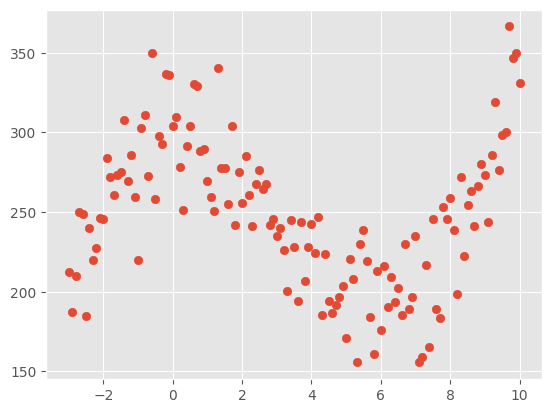

In [5]:
np.random.seed(0)

X = np.arange(-3, 10.1, 0.1)
y = X**3 - 10 * X**2 + 5*X  + 300 + np.random.normal(0.0, 25, size=X.shape)

plt.scatter(X, y)
plt.show()

# Полиномиальная регрессия аналитически, без регуляризации

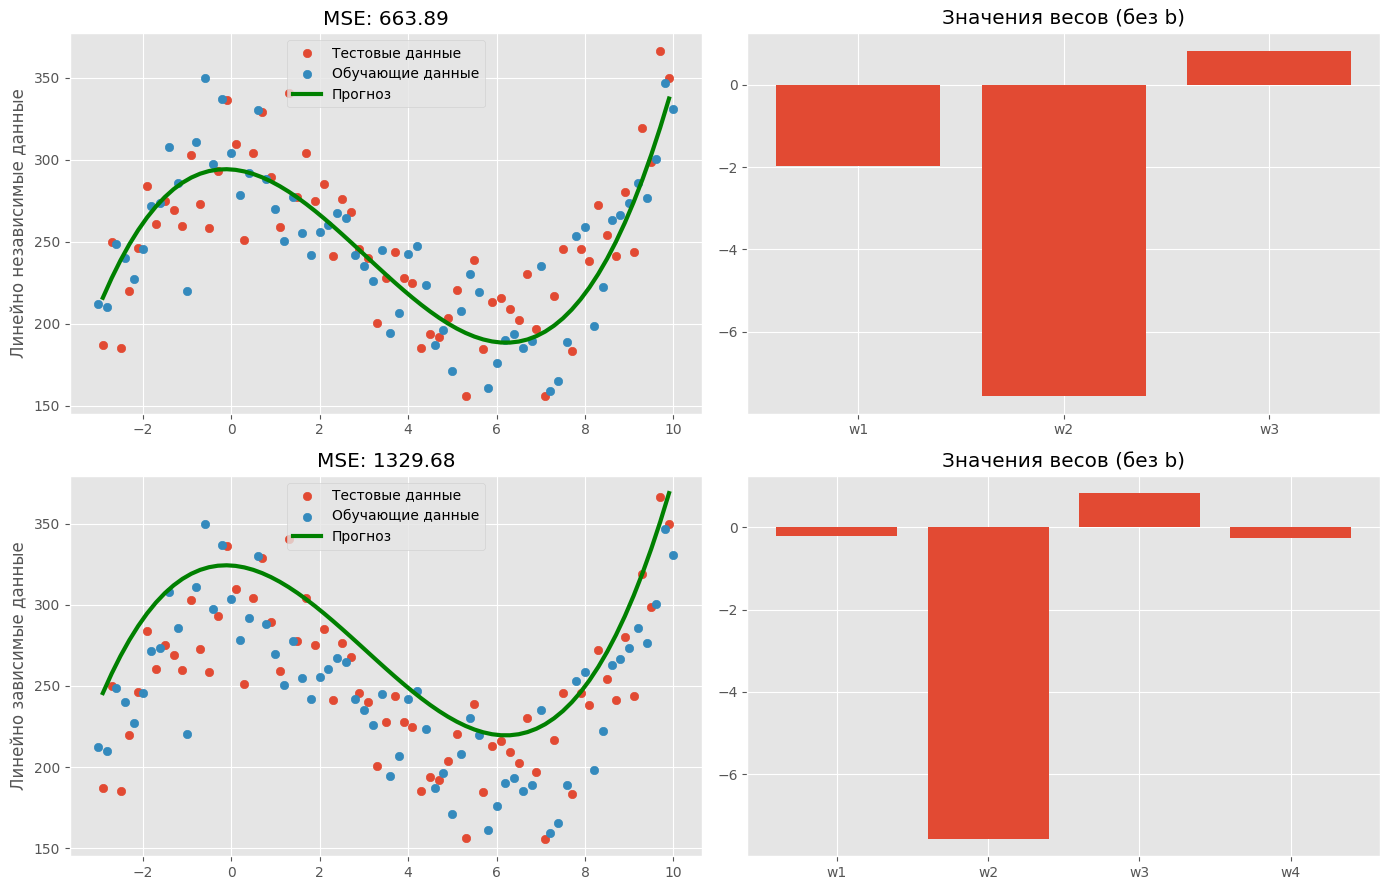

In [6]:
lr_a = LinearRegressionAnalytics()
visualize_model(X, y, lr_a)

# Полиномиальная регрессия аналитически, L2-регуляризация

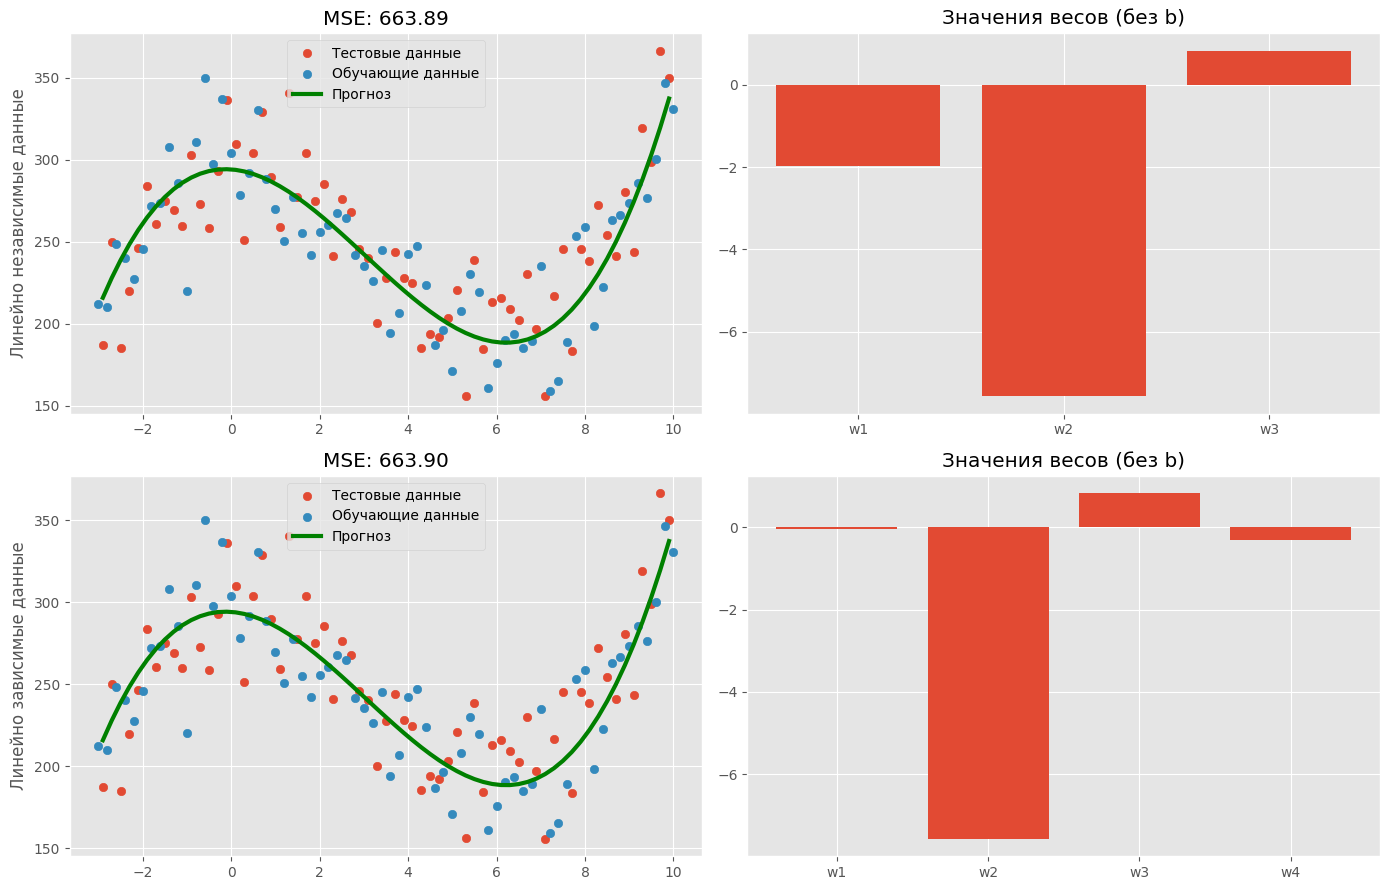

In [7]:
lr_a_l2 = LinearRegressionAnalytics(l2_coef=0.05)
visualize_model(X, y, lr_a_l2)

# Полиномиальная регрессия полным градиентным спуском, без регуляризации

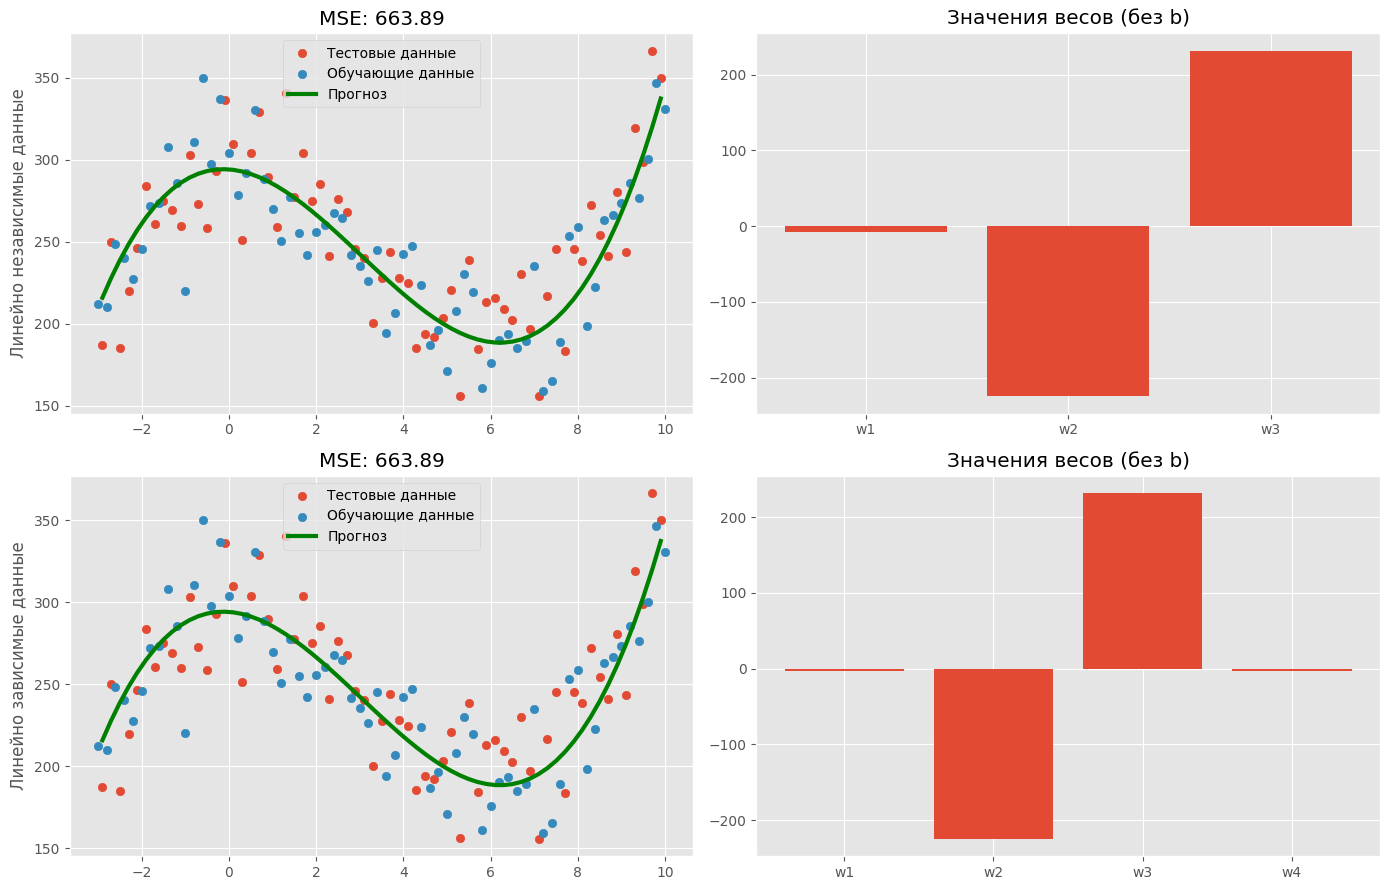

In [8]:
lr_GD = LinearRegressionGD(eta=0.25, n_iter=5000)

visualize_model(X, y, lr_GD)

# Полиномиальная регрессия полным градиентным спуском, L2-регуляризация

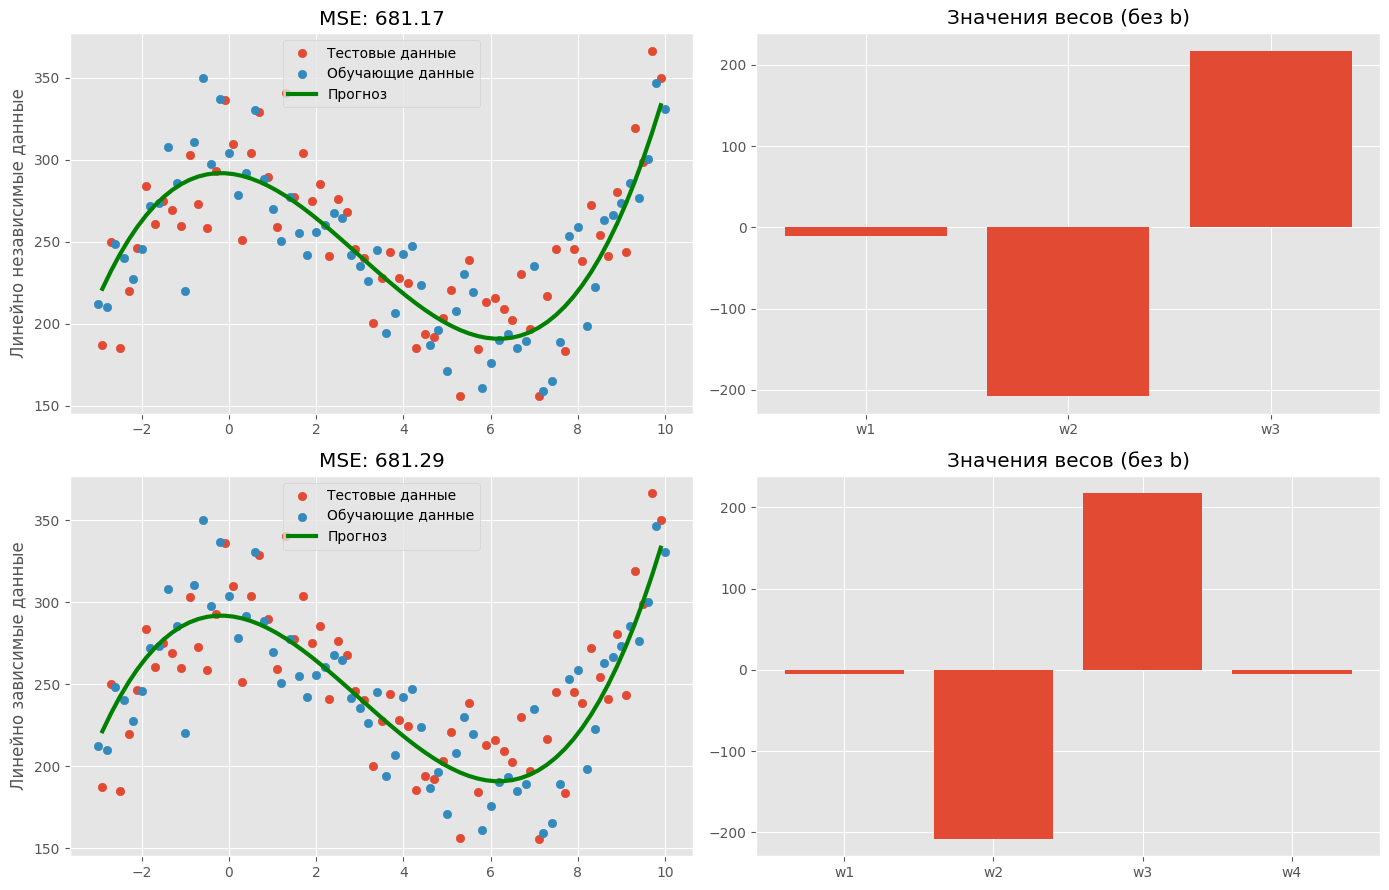

In [9]:
lr_GD_l2 = LinearRegressionGD(eta=0.25, n_iter=5000, l2_coef=0.05)

visualize_model(X, y, lr_GD_l2)